# This notebook attempts to visualize multisite activation

In [1]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import extracellular as ex
import helperFuncs as hf

### Some useful functions for later on

In [2]:
def max_depolarization_rate_sample(vec):
    # Sample where max depolarization occurs 
    peak = None

    # Determine the first derivative of vec, preserving dimensions
    v_prime1 = np.gradient(vec)
    
    # Determine the timing of the max v'
    peaks = hf.findPeaks(v_prime1,height=1,widthSamples=5)
    if len(peaks) == 0:
        peak = np.inf
    else:
        peak = peaks[0]
    
    return peak

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [3]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Load in simulated cell, real morphologies

In [4]:
# h.nrn_load_dll('../nrn/x86_64/.libs/libnrnmech.so') 

In [5]:
# h.chdir("/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src")

In [6]:
# h.load_file('stdrun.hoc')

In [7]:
# h.load_file('interpxyz.hoc')

In [8]:
# h.load_file('setpointers.hoc')

In [9]:
# h.load_file('RGC_morph_4.hoc')

In [10]:
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename,'mammalian_spike_35')
x_shift = -1000 + 997.8304687738416
RGC.shift_cell_x_y_z(0+x_shift,0,0)

After any change to cell geometry or nseg, be sure to invoke setpointers()


### Uncomment below block if you want to see segment positions

In [11]:
# Print out (x,y,z) of all the sections and segments 
for sec in RGC.section_list: 
    for ii,seg in enumerate(sec):
        print(sec.name(), ii, seg.xtra.x, seg.xtra.y, seg.xtra.z)

Cell[0].soma 0 -2.1695313453674316 0.0 -8.0
Cell[0].soma 1 -2.1695313453674316 0.0 -3.999999999999999
Cell[0].soma 2 -2.1695313453674316 0.0 2.220446049250313e-15
Cell[0].soma 3 -2.1695313453674316 0.0 4.000000000000002
Cell[0].soma 4 -2.1695313453674316 0.0 8.0
Cell[0].dend[0] 0 6.075153312874798 4.3437302003460685 -4.969561469181442
Cell[0].dend[0] 1 4.084523087122932 8.931190696405636 -10.908684407544325
Cell[0].dend[0] 2 1.9599192054342938 13.615720891258992 -16.601027847092002
Cell[0].dend[0] 3 -2.531419635988546 19.384626344457892 -17.394698610716357
Cell[0].dend[50] 0 -7.1145312786102295 19.614999771118164 -17.5
Cell[0].dend[52] 0 -10.42002367141013 16.43978499203587 -17.5
Cell[0].dend[52] 1 -14.01200811368618 13.165312634876306 -17.499999999999996
Cell[0].dend[54] 0 -17.0421644346611 10.022351623999842 -17.5
Cell[0].dend[54] 1 -18.324813600670527 6.377281116680327 -17.5
Cell[0].dend[78] 0 -21.39298086744563 4.157133053070234 -17.5
Cell[0].dend[78] 1 -26.941235997984695 2.832073

## Step 2: Setup electrical stimulus 

In [131]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'monophasic'
Stim['dt'] = .005 # units: [ms] # Prev, .005
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.2 # units: [ms] #TODO: I changed this from 0.05
Stim['stop'] = 50 # units: [ms]
Stim['amp'] = [2.05, 0] # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-1030,0,42],[-1000,0,42]] 
Stim['electrode_type'] = 'disk' # OLD: 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

# define transfer impedances 
active_x = [] # Artifact of old code, set as empty
hf.setupTransferImpedance_v3(Stim, RGC, active_x, limit_sites=False)


### Uncomment below to do a current sweet to find threshold 

In [132]:
# thr_c, t_vec, vRec_cathodic = hf.lowerThreshold_v2(Stim, RGC, lower=0, upper=5, num=25, epsilon=0.02)

## Step 3: Figure out which sections are closest to the stimulating electrodes

In [133]:
# Create a dict of segment x,y,z positions
seg_positions = {}
for sec in RGC.section_list:
    # If sec name has 'dend', skip
    if 'dend' in sec.name():
        continue
    else:
        seg_positions[sec.name()] = []
        for seg in sec:
            seg_positions[sec.name()].append([seg.xtra.x,seg.xtra.y,seg.xtra.z])


In [134]:
# For each stimulating electrode, figure out which segment is closest to it
for elec in Stim['electrodes']:
    print('Electrode: ', elec)
    dist_to_elec = np.inf
    for sec in seg_positions:
        for ii,seg in enumerate(seg_positions[sec]):
            dist = np.sqrt((seg[0]-elec[0])**2 + (seg[1]-elec[1])**2 + (seg[2]-elec[2])**2)
            if dist < dist_to_elec:
                dist_to_elec = dist
                seg_id = ii
                closest_seg = [sec,seg_id]
    print('Closest segment: compartment = ', closest_seg[0], ' segID = ', closest_seg[1])
    print('Closest seg coordinates: ', seg_positions[closest_seg[0]][closest_seg[1]])
    print('----------------------------------------------------------------------------')

Electrode:  [-1030, 0, 42]
Closest segment: compartment =  Cell[0].axon  segID =  172
Closest seg coordinates:  [-1029.9999786218007, 0.0, 29.94091033935547]
----------------------------------------------------------------------------
Electrode:  [-1000, 0, 42]
Closest segment: compartment =  Cell[0].axon  segID =  166
Closest seg coordinates:  [-999.9999783039091, 0.0, 29.94091033935547]
----------------------------------------------------------------------------


## Step 4: Set up recording vectors before running the stimulation

### Current recording vectors at all segment compartments

In [135]:
# Setup dictionary to capture iOut at all cell compartments
iOut = {}
iOut['axon'] = {}
h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
for i,seg in enumerate(RGC.axon):
    iOut['axon']['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Voltage recording vectors at all segment compartments 

In [136]:
# set up recording vectors at every axonal segment 
vRec_axon = []
for seg in RGC.axon:
    vRec_axon.append(h.Vector().record(RGC.axon(seg.x)._ref_v))

### Time vector

In [137]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

### Record Na membrane current

In [138]:
iNa_axon = []
for seg in RGC.axon:
    iNa_axon.append(h.Vector().record(seg._ref_ina))

## Step 5: Apply stimulus to the cell! 

In [139]:
# Use APCount to detect if an AP occured
APC_axon = h.APCount(1, sec = RGC.axon)
APC_axon.thresh = 0 

# Play the stimulus into the cell, setting it up for stimulation
tsvec, isvec = hf.setupStimulus_unit(Stim)
isvec.play(h._ref_is_xtra, tsvec, 1) 

# Initialization phase of the simulation 
h.init()
h.tstop = Stim['initDur']
h.dt = Stim['initDt']
h.finitialize(Stim['vInit'])
h.continuerun(h.tstop)

# Run the simulation 
h.tstop = Stim['initDur'] + Stim['stop']
h.steps_per_ms = int(1/Stim['dt'])
h.dt = Stim['dt']
h.continuerun(h.tstop)
print('***** sim done *****')

***** sim done *****


## Step 6: Determine point of spike initiation

In [140]:
## -- if spike, increment spike count and record initSeg
spike = 0
min_peaks_inds = []
init_time = np.inf
if APC_axon.n > 0:
    spike_timing = APC_axon.time
    if spike_timing > 50 and spike_timing < 70:
        spike = 1
        print('SPIKE: Currents: ', Stim['amp'], 'uA')
        # Determine where it started
        ### ---- Logic to record spike initiation segment ----
        t_vec = np.array(t)
        vRecord = np.array(vRec_axon)
        # First, truncate out first 50 time samples (initDur)
        vRecord_trunc = vRecord[:,int(Stim['initDur']/Stim['initDt']):]
        t_trunc = t_vec[int(Stim['initDur']/Stim['initDt']):]
        # # Second, truncate initial delay period (delay)
        # vRecord_trunc = vRecord_trunc[:,int((Stim['delay']+Stim['dur']*3+Stim['dt']*3)/Stim['dt']):]
        # t_trunc = t_trunc[int((Stim['delay']+Stim['dur']*3+Stim['dt']*3)/Stim['dt']):]
        # Second, truncate initial delay period (delay)
        vRecord_trunc = vRecord_trunc[:,int((Stim['delay']+Stim['dur']*1+Stim['dt']*1)/Stim['dt']):]
        t_trunc = t_trunc[int((Stim['delay']+Stim['dur']*1+Stim['dt']*1)/Stim['dt']):]
        # --- find max v point ------
        peaks_list = []
        for ii in range(vRecord_trunc.shape[0]):
            vec = vRecord_trunc[ii,:]
            # Find the peaks of the vec waveform 
            # peaks = hf.findPeaks(vec,height=-10,widthSamples=15)
            peaks = hf.findPeaks(vec,height=-10,widthSamples=10)
            if len(peaks) == 0:
                peaks_list.append(np.inf)
            else:
                peaks_list.append(peaks[0])
        
        min_peaks = np.min(peaks_list)
        min_peaks_inds = [i for i, x in enumerate(peaks_list) if x == min_peaks]
        init_time = t_trunc[peaks_list[min_peaks_inds[0]]]
        #### ---------
        # # --- find max v' point ------
        # peaks_list = []
        # for ii in range(vRecord_trunc.shape[0]):
        #     vec = vRecord_trunc[ii,:]
        #     # Find the peaks of the vec waveform 
        #     peak = max_depolarization_rate_sample(vec)
        #     peaks_list.append(peak)
        
        # min_peaks = np.min(peaks_list)
        # min_peaks_inds = [i for i, x in enumerate(peaks_list) if x == min_peaks]
        # init_time = t_trunc[peaks_list[min_peaks_inds[0]]]
        # #### ---------

    else:
        print('SPIKE TIME NOT MET: Currents: ', Stim['amp'], 'uA')
else:
    print('NO SPIKE: Currents: ', Stim['amp'], 'uA')

NO SPIKE: Currents:  [2.05, 0] uA


In [141]:
print(min_peaks_inds)
print(init_time)

[]
inf


### Try to plot rx profile (transfer resistance)

In [126]:
transfer_rx = []
for seg in RGC.axon:
    transfer_rx.append(seg.xtra.rx)

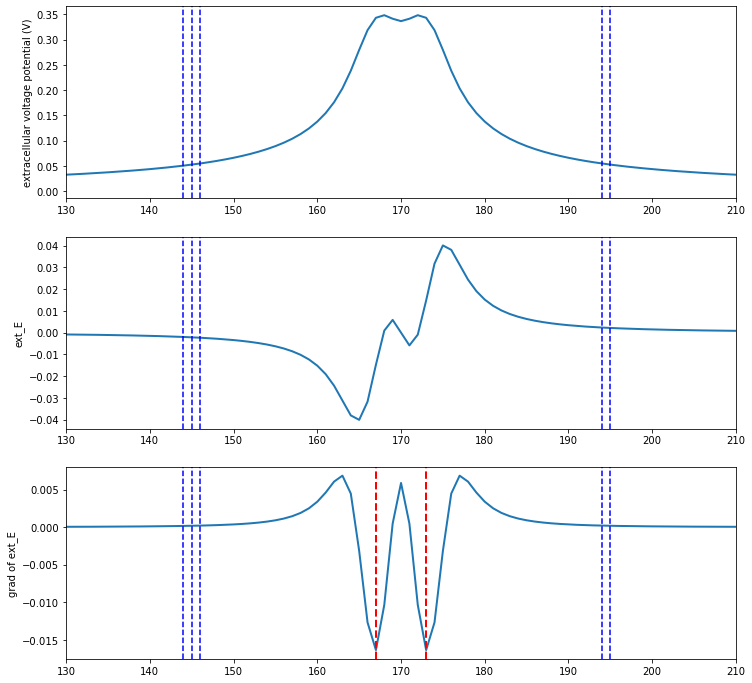

In [127]:
x_seg = np.arange(1,len(transfer_rx)+1)

fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(12,12))

## First, plot V
ax1.plot(x_seg,transfer_rx,linewidth=2)

# Zoom into around the stim elecs
ax1.set_xlim([130,210])
ax1.set_ylabel('extracellular voltage potential (V)')

# Add vertical lines where spike initiation likely occured according to model
for ii in min_peaks_inds:
    ax1.axvline(x=ii+1, color='blue', linestyle='--')

## Now plot dV/dx 
ex_v_prime = -1*np.gradient(transfer_rx)
ax2.plot(x_seg,ex_v_prime,linewidth=2)

# Zoom into around the stim elecs
ax2.set_xlim([130,210])
ax2.set_ylabel('ext_E')

# Add vertical lines where spike initiation likely occured according to model
for ii in min_peaks_inds:
    ax2.axvline(x=ii+1, color='blue', linestyle='--')


## Now plot d2V/dx2
ex_v_prime2 = -1*np.gradient(ex_v_prime)
ax3.plot(x_seg,ex_v_prime2,linewidth=2)

# Zoom into around the stim elecs
ax3.set_xlim([130,210])
ax3.set_ylabel('grad of ext_E')

# Add vertical lines where spike initiation likely occured according to model
for ii in min_peaks_inds:
    ax3.axvline(x=ii+1, color='blue', linestyle='--')

# Add vertical lines at the electrodes 
ax3.axvline(x=173, color='red', linewidth=2, linestyle='--')
ax3.axvline(x=167, color='red', linewidth=2, linestyle='--')


Text(0, 0.5, 'membrane voltage [mV]')

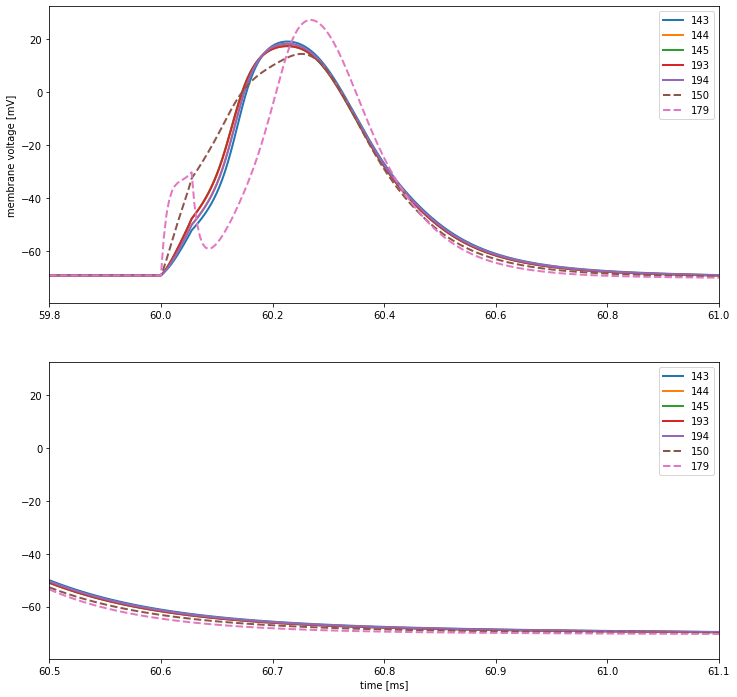

In [130]:
# Plot the actual spike at certain test segments 
fig, (ax,ax2) = plt.subplots(2,1,figsize=(12,12))

# seg1 = 194
# ax.plot(t,vRecord[seg1+1],linewidth=2, color = 'black', label=str(seg1))

# seg2 = 178
# ax.plot(t,vRecord[seg2+1],linewidth=2, color = 'orange', label=str(seg2))

for seg in min_peaks_inds:
    ax.plot(t,vRecord[seg],linewidth=2, label=str(seg))
    ax2.plot(t,vRecord[seg],linewidth=2, label=str(seg))

seg = 150
ax.plot(t,vRecord[seg],linewidth=2,linestyle='--',label=str(seg))
ax2.plot(t,vRecord[seg],linewidth=2,linestyle='--',label=str(seg))

seg = 179
ax.plot(t,vRecord[seg],linewidth=2,linestyle='--',label=str(seg))
ax2.plot(t,vRecord[seg],linewidth=2,linestyle='--',label=str(seg))

# # Add a vertical line at 60.15 (end of stimulus)
# ax.axvline(x=60.151, color='grey', linestyle='--')

ax.set_xlim([59.8,61])
ax.legend()

ax2.set_xlim([60.5,61.1])
ax2.legend()
ax2.set_xlabel('time [ms]')
ax.set_ylabel('membrane voltage [mV]')

# indx_min = hf.findPeaks(vRecord_trunc[seg2+1],height=-10,widthSamples=10)
# print(indx_min)
# print(t[indx_min[0]])


In [129]:
print(t_trunc)

[ 60.055  60.06   60.065 ...  99.99   99.995 100.   ]


## Other code below

In [424]:
t_trunc[peaks_list[165]]

60.274999999990655

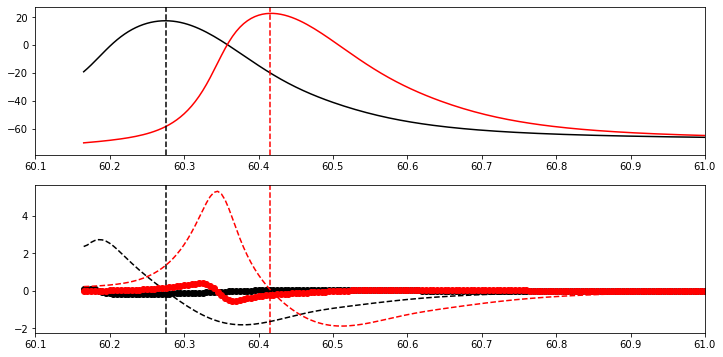

In [425]:
seg1 = 166
vec = vRecord_trunc[seg1,:]
v_prime1 = np.gradient(vec)
v_prime2 = np.gradient(v_prime1)

seg2 = 136
vec_2 = vRecord_trunc[seg2,:]
v_prime1_2 = np.gradient(vec_2)
v_prime2_2 = np.gradient(v_prime1_2)

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,6))

ax1.plot(t_trunc,vec,c='k')
ax1.plot(t_trunc,vec_2,c='r')

# Plot dashed line at calculated peak
ax1.axvline(t_trunc[peaks_list[seg1]], color='k', linestyle='--')
ax1.axvline(t_trunc[peaks_list[seg2]], color='r', linestyle='--')
ax2.axvline(t_trunc[peaks_list[seg1]], color='k', linestyle='--')
ax2.axvline(t_trunc[peaks_list[seg2]], color='r', linestyle='--')


ax2.plot(t_trunc,v_prime1,'k--')
ax2.plot(t_trunc,v_prime2,'ko')
ax2.plot(t_trunc,v_prime1_2,'r--')
ax2.plot(t_trunc,v_prime2_2,'ro')

ax1.set_xlim(60.1,61)
ax2.set_xlim(60.1,61)
plt.show()

### Look at Na currents 

(2000.0, 2200.0)

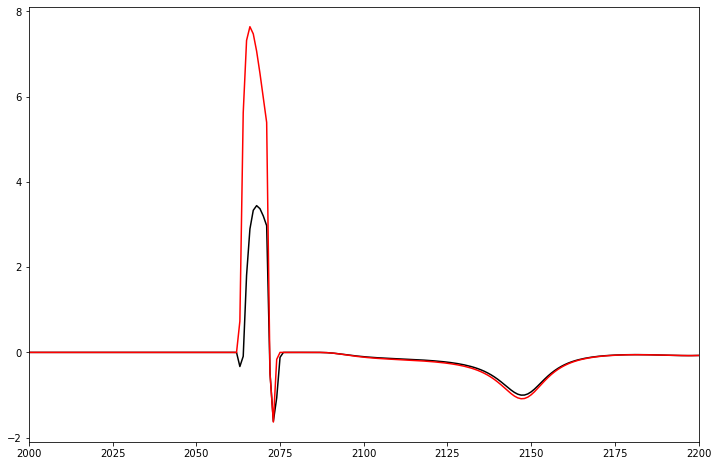

In [41]:
fig,ax = plt.subplots(1,1,figsize=(12,8))
ax.plot(iNa_axon[seg1],c='k')
ax.plot(iNa_axon[seg2],c='r')
ax.set_xlim([2000,2200])

## Step 6: Visualize AP

### Plot membrane voltage at each axon segment, showing AP bifurcating prop. (spatial view)

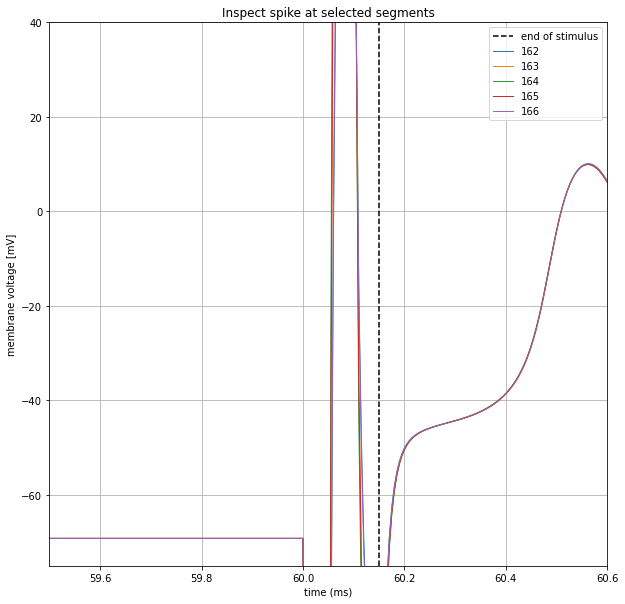

In [42]:
fig, ax = plt.subplots(1,1,figsize=(10,10))
ax.grid()
ax.set_xlim(59.5,60.6)
ax.set_ylim(-75,40)
ax.axvline(60.15, color='k', linestyle='--', label='end of stimulus')

for idx in min_peaks_inds:
    ax.plot(t_vec,vRec_axon[idx],linewidth=1,label=f'{idx}')

    ax.set_title(f'Inspect spike at selected segments')
    ax.set_xlabel('time (ms)')
    ax.set_ylabel('membrane voltage [mV]')


ax.legend()
plt.show()

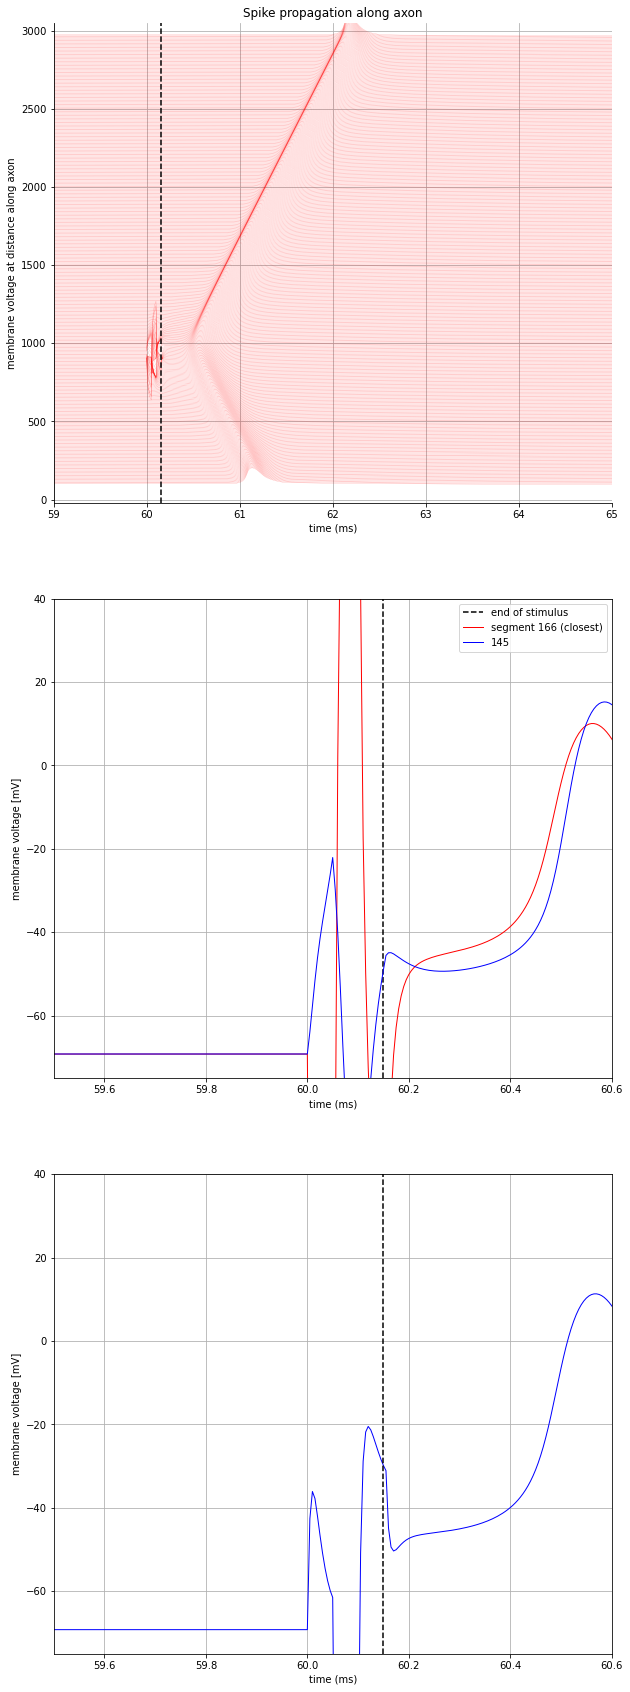

In [43]:
# Example of plotting voltage traces at all axonal segments, tracking spike
#  propagation along the membrane, expanding across space
fig, (ax,ax2,ax3) = plt.subplots(3,1,figsize=(10,30))
ax.grid()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

offset = 170
offset_step = 5
for i in range(len(vRec_axon)):
    ax.plot(t_vec,vRec_axon[i]+offset,'r',linewidth=0.2, alpha=0.5)

    offset += offset_step

dur = Stim['dur']
ax.set_title(f'Spike propagation along axon')
ax.set_xlabel('time (ms)')
ax.set_ylabel('membrane voltage at distance along axon')

ax.set_xlim(59,65)
ax.set_ylim(-20,int(len(vRec_axon))*offset_step+170)
# ax.set_ylim(900,1100)
ax.axvline(60.15, color='k', linestyle='--', label='end of stimulus')

## Now, plot the spike at closest seg to electrode
seg = 166
ax2.axvline(60.15, color='k', linestyle='--', label='end of stimulus')
ax2.plot(t_vec,vRec_axon[seg],'r',linewidth=1,label='segment 166 (closest)')

# ax2.set_title(f'Inspect spike at closest seg to electrode\nsegment={seg}\nseg_position={seg_positions["Cell[0].axon"][seg]}')
ax2.set_xlabel('time (ms)')
ax2.set_ylabel('membrane voltage [mV]')

ax2.grid()
ax2.set_xlim(59.5,60.6)
ax2.set_ylim(-75,40)


seg = 145
ax2.plot(t_vec,vRec_axon[seg+1],'b',linewidth=1,label=f'{seg}')

ax2.legend()


## Finally, plot the spike at seg of spike 
# seg = init_seg
seg = 170
ax3.plot(t_vec,vRec_axon[seg+1],'b',linewidth=1)

# ax3.set_title(f'Inspect spike at init_seg\nsegment={seg}\nseg_position={seg_positions["Cell[0].axon"][seg]}')
ax3.set_xlabel('time (ms)')
ax3.set_ylabel('membrane voltage [mV]')

ax3.grid()
ax3.set_xlim(59.5,60.6)
ax3.set_ylim(-75,40)
ax3.axvline(60.15, color='k', linestyle='--', label='end of stimulus')

plt.show()

### Plot membrane voltage vs time overlaid for every seg (temportal view)

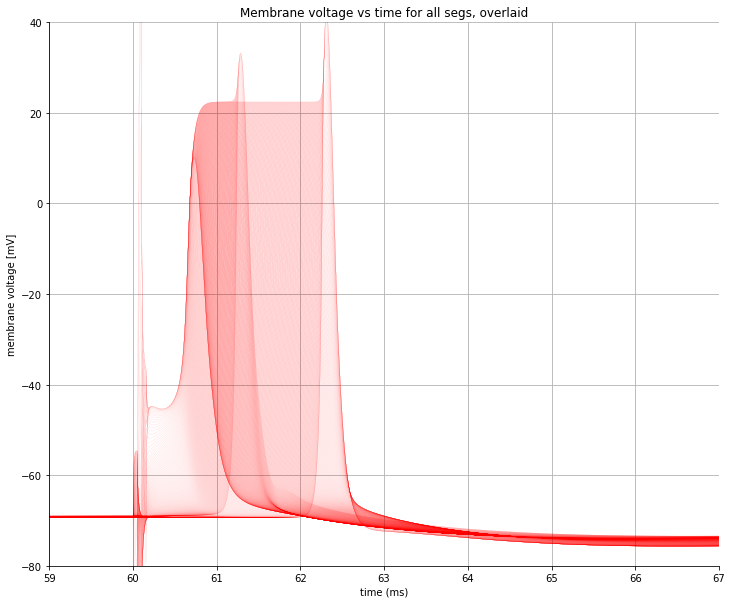

In [26]:
fig, ax = plt.subplots(1,1,figsize=(12,10))
ax.grid()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

for i in range(len(vRec_axon)):
    ax.plot(t_vec,vRec_axon[i],'r',linewidth=0.1, alpha=0.3)

ax.set_title(f'Membrane voltage vs time for all segs, overlaid')
ax.set_xlabel('time (ms)')
ax.set_ylabel('membrane voltage [mV]')

ax.set_xlim(59,67)
ax.set_ylim(-80,40)
plt.show()

## --- IGNORED SCRAP CODE BELOW -- (for debugging)

### Extracellular recording as observed from a given recording electrode (point source approx)

In [16]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-100,0,7]

# setup vector where to store extracellular voltage profile
timeStepsRec = int(Stim['stop']/Stim['dt'])+1
dtFac = 1
recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for k,seg in enumerate(axon):
    # Compute distance from electrode to center of each segment [um]
    dist = np.sqrt((seg.xtra.x-recElec[0])**2 + (seg.xtra.y-recElec[1])**2 \
                    + (seg.xtra.z-recElec[2])**2)
    
    # Set transfer impedance for each segment [MOhm]
    tf = Stim['rhoExt'] / (4.0*np.pi*dist*(1e-4)) * 1e-6

    # recOut units: 1e3*MOhm*nA == uV
    recOut += 1e3 * tf * \
        (iOut['axon']['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

Text(0, 0.5, 'Extracellular voltage [uV]')

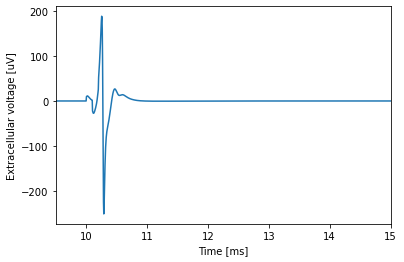

In [17]:
# Plot extracellular voltaged recorded on recElec
plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

### Now try with disk electrode approximations

In [18]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-100,0,7]

# setup vector where to store extracellular voltage profile
timeStepsRec = int(Stim['stop']/Stim['dt'])+1
dtFac = 1
recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for k, seg in enumerate(axon):
    # Distance from electrode to center of each segment [cm]
    r = 1e-4*\
        np.sqrt((seg.xtra.x - (recElec[0]))**2\
                + (seg.xtra.y - (recElec[1]))**2)
    # Vertical distance [cm]
    z = 1e-4*(seg.xtra.z-recElec[2])

    # Transfer impedance [MOhm]  
    rDisk = 1e-4*Stim['elecDiam']/2             
    tf = 1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
        * np.arcsin((2*rDisk) / \
        (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2)))
                
    # recOut units: 1e3*MOhm*nA == uV
    recOut += 1e3 * tf * \
        (iOut['axon']['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

Text(0, 0.5, 'Extracellular voltage [uV]')

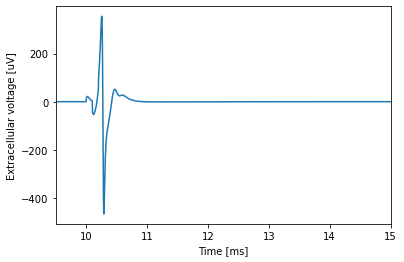

In [19]:
# Plot extracellular voltaged recorded on recElec
plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

### Plot voltage trace to see if there was an AP 

Text(0, 0.5, 'Distance along axon (um)')

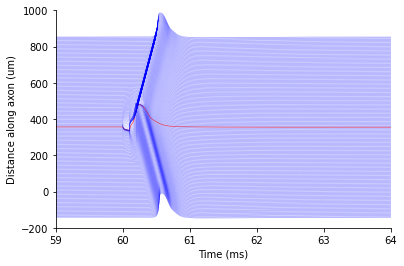

In [20]:
vInit = -70
numSeg = axon.nseg
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
offset = Stim['vInit']
for cnt in range(numSeg):
    if cnt==numSeg/2:
        plt.plot(t,np.array(vRec[cnt])+offset,'r',linewidth=0.5)
    else:
        plt.plot(t,np.array(vRec[cnt])+offset,'b',linewidth=0.1)
    offset += 2
plt.xlim(Stim['initDur']+9,Stim['initDur']+14)
plt.ylim(-200,1000)
plt.xlabel('Time (ms)')
plt.ylabel('Distance along axon (um)')

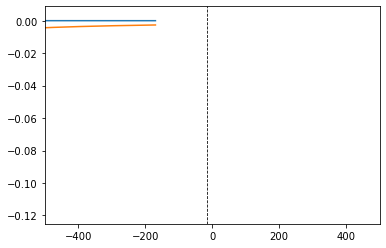

In [50]:
x_loc = []
rx = []
for seg in RGC.axon:
    x_loc.append(seg.xtra.x)
    rx.append(seg.xtra.rx)

# Calculate first numerical derivative of rx along x_loc
rx = np.array(rx)
x_loc = np.array(x_loc)
rx_grad = np.gradient(rx,x_loc)

# Plot rx and rx_grad
plt.figure()
plt.plot(x_loc,rx_grad)
plt.plot(x_loc,rx)
plt.xlim(-500,500)
plt.axvline(-15,color='k',linestyle='--',linewidth=0.8)


# plt.plot(x_loc,rx)
# plt.xlim(-200,200)
# plt.axvline(-15,color='k',linestyle='--',linewidth=0.8)
